**Loading dependencies and data**

In [39]:
import sys
sys.argv=['python', '--full']
import dlc_practical_prologue as prologue
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
%matplotlib widget


**Problem 1 (Practical)**

In [40]:
train_input, train_target, test_input, test_target=prologue.load_data()
print(train_input.shape)
print(train_target.shape)
print(test_input.shape)
print(test_target.shape)

def nearest_classification(train_input, train_target, x):
    _d=torch.sum(torch.pow((train_input-x),2), dim=1)
    _, indices=torch.min(_d, dim=0)
    return train_target[indices]

print("Prediction:", nearest_classification(train_input, train_target, test_input[0]))
print("Actual:", test_target[0])
print("Correct:", test_target[0]==nearest_classification(train_input, train_target, test_input[0]))

# correct=0
# for i in range(test_input.shape[0]):
#     pred=nearest_classification(train_input, train_target, test_input[i])
#     correct += (pred==test_target[i]).item()
    
# print(f"Accuracy: {correct/test_input.shape[0]}")

* Using MNIST
** Use 60000 train and 10000 test samples
torch.Size([60000, 784])
torch.Size([60000])
torch.Size([10000, 784])
torch.Size([10000])
Prediction: tensor(7)
Actual: tensor(7)
Correct: tensor(True)


**Problem 2 (Practical)**

In [41]:
# Basically completed above.

**Problem 3 (Practical)**

In [42]:
def PCA(x):
    x_bar=torch.mean(x, dim=0)
    x=x-x_bar
    eigen_values,eigen_vectors=torch.linalg.eigh((1/(x.shape[0]-1))*(x.T@x))
    eigen_values,eigen_vectors=eigen_values.flip(dims=[0]),eigen_vectors.flip(dims=[1])
    return (x_bar,eigen_vectors)


**Problem 4 (Practical)** Commented to avoid long runtime.

In [ ]:
# mean, eigen_vectors = PCA(train_input)

# random_basis_100d= torch.randn((784, 100))

# dimensions = [3, 10, 50, 100]
# for dim in dimensions:
#     train_pca = (train_input - mean) @ eigen_vectors[:, :dim]
#     test_pca = (test_input - mean) @ eigen_vectors[:, :dim]

#     correct_pca = 0
#     for i in range(test_pca.shape[0]):
#         prediction = nearest_classification(train_pca, train_target, test_pca[i])
#         correct_pca += (prediction == test_target[i]).item()
    
#     pca_accuracy = correct_pca / test_pca.shape[0]
#     print(f"PCA with {dim} dimensions - Accuracy: {pca_accuracy:.4f}")

# train_rand = (train_input - mean) @ random_basis_100d
# test_rand = (test_input - mean) @ random_basis_100d

# correct_rand = 0
# for i in range(test_rand.shape[0]):
#     prediction = nearest_classification(train_rand, train_target, test_rand[i])
#     correct_rand += (prediction == test_target[i]).item()

# rand_accuracy = correct_rand / test_rand.shape[0]
# print(f"Random projection with 100 dimensions - Accuracy: {rand_accuracy:.4f}")

PCA with 3 dimensions - Accuracy: 0.4428
PCA with 10 dimensions - Accuracy: 0.9137
PCA with 50 dimensions - Accuracy: 0.9734
PCA with 100 dimensions - Accuracy: 0.9716


KeyboardInterrupt: 

**Problem 1 (Homework)** 

In [ ]:
def k_NN_classification(train_input, train_target, x, k):
    _d=torch.linalg.norm(train_input-x, dim=1) # l2 distances
    _t=torch.argsort(_d)[:k] # top k
    _d=_d[_t] # top k l2 distances
    _l=train_target[_t] # top k labels
    _w = 1.0 / (_d + 1e-5) # weights to determine labeling
    class_weights = torch.zeros(10) # initialize the class weights
    class_weights.scatter_add_(0, _l.long(), _w) # add weights to each class
    return torch.argmax(class_weights) # return the class with the highest weight

**Problem 2 (Homework)**

In [ ]:
def compute_k_NN_errors(train_input, train_target, test_input, test_target, k, mean=None, proj=None):
    if mean is not None and proj is not None:
        train_input = (train_input - mean) @ proj
        test_input = (test_input - mean) @ proj
    
    correct = 0
    for i in range(test_input.shape[0]):
        prediction = k_NN_classification(train_input, train_target, test_input[i], k)
        correct += (prediction == test_target[i]).item()
    
    return 1 - (correct / test_input.shape[0])


**Problem 3 (Homework)**

* Using MNIST
** Use 60000 train and 10000 test samples
torch.Size([5000, 784])
torch.Size([5000])
torch.Size([1000, 784])
torch.Size([500, 784])
torch.Size([3500, 784])
k=1, Validation Error: 0.0760
k=2, Validation Error: 0.0760
k=4, Validation Error: 0.0800
k=8, Validation Error: 0.0760
k=16, Validation Error: 0.1000
k=32, Validation Error: 0.1120


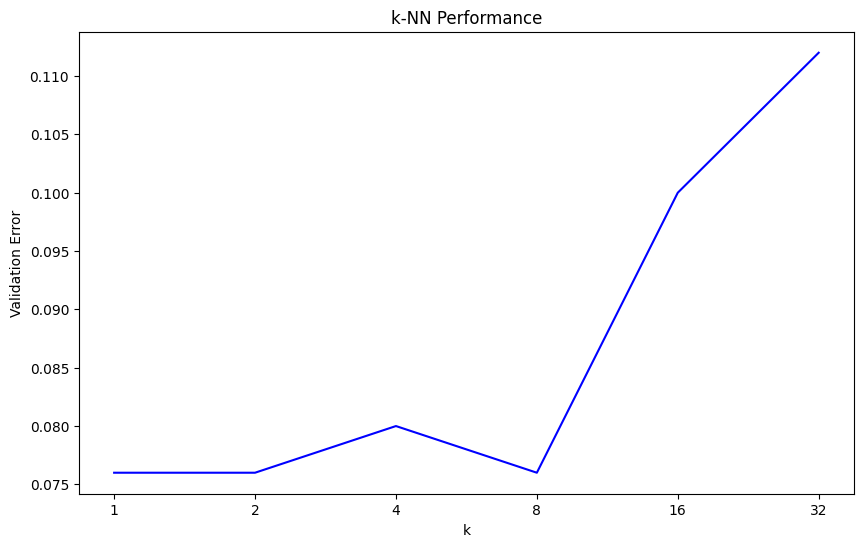

k=1, Test Error: 0.0720
k=2, Test Error: 0.0720
k=4, Test Error: 0.0680
k=8, Test Error: 0.0710
k=16, Test Error: 0.0810
k=32, Test Error: 0.1000


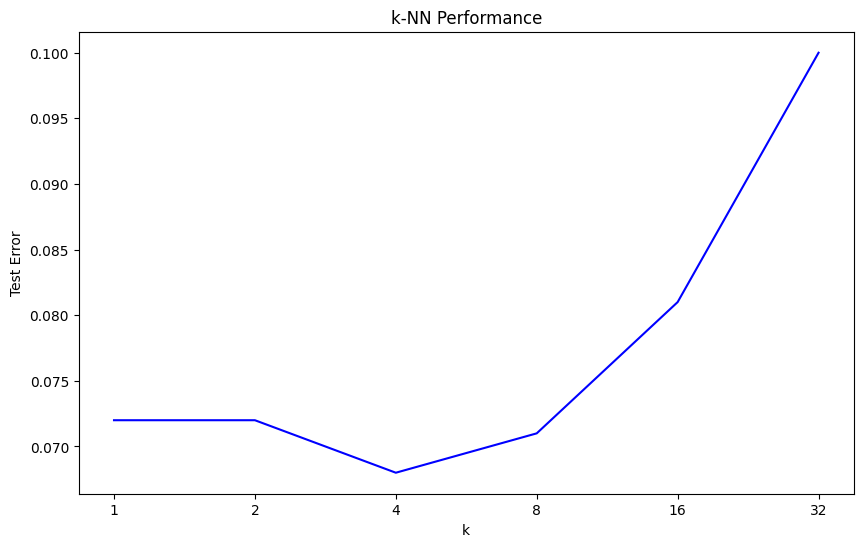

In [ ]:
train_input, train_target, test_input, test_target=prologue.load_data()
_i = torch.randperm(train_input.size(0))
_t_data_input = train_input[_i[:5000]]
_t_data_target = train_target[_i[:5000]]
print(_t_data_input.shape)
print(_t_data_target.shape)
if _t_data_input.max() > 1.0:
    _t_data_input = _t_data_input / 255.0

test_input = _t_data_input[:1000]
test_target = _t_data_target[:1000]
val_input = _t_data_input[1000:1500]
val_target = _t_data_target[1000:1500]
train_target = _t_data_target[1500:]
train_input = _t_data_input[1500:]
print(test_input.shape)
print(val_input.shape)
print(train_input.shape)

k = [1, 2, 4, 8, 16, 32]
k_errors = []
for i in k:
    error = compute_k_NN_errors(train_input, train_target, val_input, val_target, i)
    k_errors.append(error)

    print(f"k={i}, Validation Error: {error:.4f}")

plt.figure(figsize=(10, 6))
plt.plot([str(i) for i in k], k_errors, color='blue')
plt.xlabel('k')
plt.ylabel('Validation Error')
plt.title('k-NN Performance')
plt.show()

k_errors = []
for i in k:
    error = compute_k_NN_errors(train_input, train_target, test_input, test_target, i)
    k_errors.append(error)

    print(f"k={i}, Test Error: {error:.4f}")

plt.figure(figsize=(10, 6))
plt.plot([str(i) for i in k], k_errors, color='blue')
plt.xlabel('k')
plt.ylabel('Test Error')
plt.title('k-NN Performance')
plt.show()



*Short Analysis*: Viewing both the validation error and test error rates, it can be seen that the best k is 4 out of the available k values typically. As k increases past four, the error trends upwards as oversmoothing/overfitting, as more variance/noise is included from surrounding neighbors that may not be of the same class/label as intended.

**Problem 4 (Homework)**

* Using CIFAR


/home/takeshi-stormer/Homework-Repository/env/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


** Use 50000 train and 10000 test samples


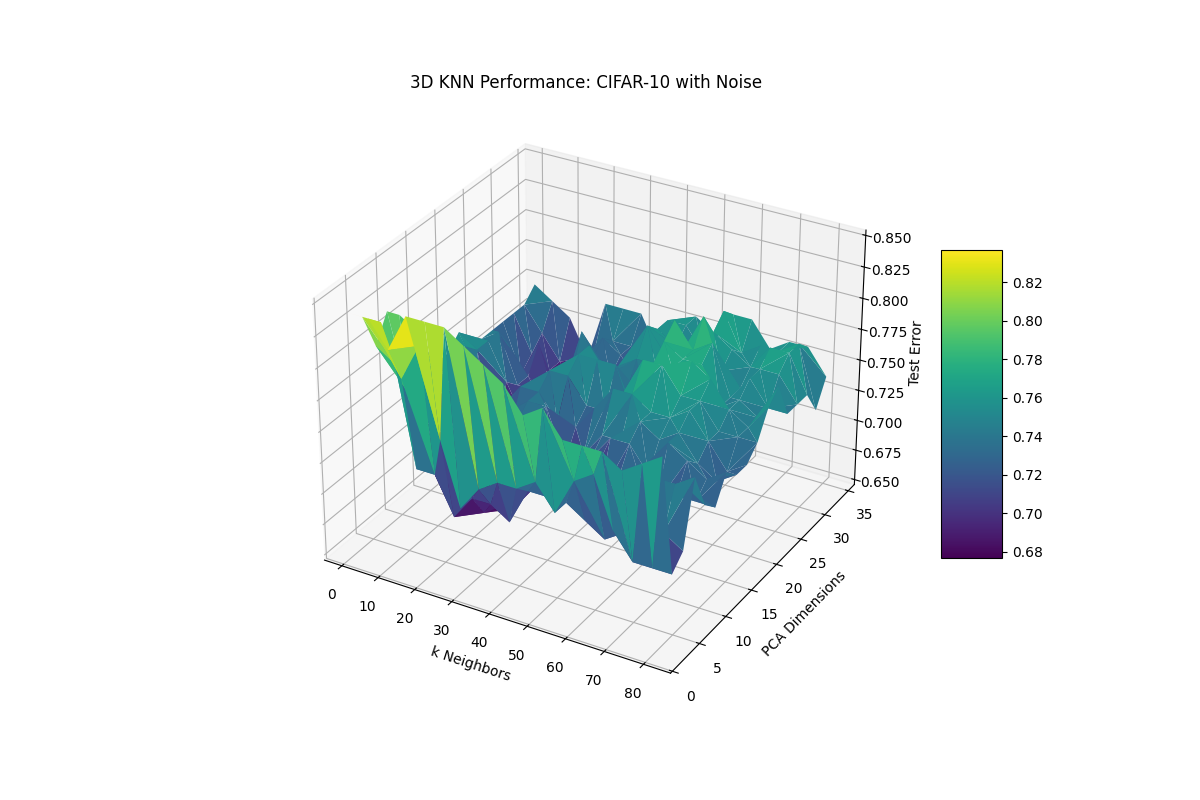

In [ ]:
# Taken from above

def PCA(x):
    x_bar=torch.mean(x, dim=0)
    x=x-x_bar
    eigen_values,eigen_vectors=torch.linalg.eigh((1/(x.shape[0]-1))*(x.T@x))
    eigen_values,eigen_vectors=eigen_values.flip(dims=[0]),eigen_vectors.flip(dims=[1])
    return (x_bar,eigen_vectors)

train_input_full, train_target_full, _, _ = prologue.load_data(cifar=True)
_i = torch.randperm(train_input_full.size(0))
_t_data_input = train_input_full[_i[:500]]
_t_data_target = train_target_full[_i[:500]]
if _t_data_input.max() > 1.0:
    _t_data_input = _t_data_input / 255.0
test_input = _t_data_input[:100]
test_target = _t_data_target[:100]
train_input = _t_data_input[100:]
train_target = _t_data_target[100:]
train_input = train_input + 0.05 * torch.randn_like(train_input)

dimensions = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34]
k = [1, 6, 11, 16, 21, 26, 31, 36, 41, 46, 51, 56, 61, 66, 71, 76, 81]
# Uncomment for original problem values.
# dimensions = [5, 10, 20]
# k = [1, 5, 10, 20, 40, 80]
errors = {}

for dim in dimensions:
    mean, eigen_vectors = PCA(train_input)
    errors[dim] = {}
    # Uncomment to print the individual errors
    # print(f"PCA with {dim} dimensions:")
    for i in k:
        error = compute_k_NN_errors(train_input, train_target, test_input, test_target, i, mean, eigen_vectors[:, :dim])
        errors[dim][i] = error
        # Uncomment to print the individual errors
        # print(f"  k={i}, Test Error: {error:.4f}")


# 1. Prepare Data
x_k = []
y_dim = []
z_error = []

for dim in dimensions:
    for i in k:
        x_k.append(i)
        y_dim.append(dim)
        z_error.append(errors[dim][i])

# 2. Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Using plot_trisurf because it handles irregular grids well
surf = ax.plot_trisurf(x_k, y_dim, z_error, cmap='viridis', edgecolor='none')

ax.set_xlabel('k Neighbors')
ax.set_ylabel('PCA Dimensions')
ax.set_zlabel('Test Error')
ax.set_title('3D KNN Performance: CIFAR-10 with Noise')

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()


*Short Analysis*: It can be seen that the trend where increase in the value of k corresponds to oversmoothing, and a similar trend is seen as the number of dimensions increase as well. This leaves the best performance occuring between 10-30 neighbors and 5-15 dimensions. This can sort of be visualized by looking at the 3d graph from above and noticing a valley occuring on the region encompassing 10 to 30 neighbors. 

Given by the fact noise is added to the images, while also inherently being much more noisery than the MNIST data, it would make sense as to why the misclassification rate is far greater in the classification of CIFAR data. It can also be noted that the amount of data being trained on in the CIFAR case is much less than the MNIST case.